In [17]:
#Instructions: run each cell one after the other to load data, generate dictionaries, and plot graphs
#Note: replace file paths with your file paths 

In [18]:
import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict
from matplotlib.patches import Patch

In [19]:
el_DA_gamma0 =  pd.read_excel (r'resultsProposed_alpha.xlsx', sheet_name='elEDA')
el_DA_gamma0 = el_DA_gamma0['elDA']
el_DA_gamma0 = el_DA_gamma0[0:]

In [20]:
elDA1 = []
elDA2 = []
elDA3 = []
elDA4 = []
elDA5 = []
elDA6 = []
elDA7 = []
elDA8 = []
elDA9 = []
elDA10 = []
elDA11 = []



In [21]:
for i in range (0, len(el_DA_gamma0), 11):
    elDA1.append(el_DA_gamma0[i])
    elDA2.append(el_DA_gamma0[i+1])
    elDA3.append(el_DA_gamma0[i+2])
    elDA4.append(el_DA_gamma0[i+3])
    elDA5.append(el_DA_gamma0[i+4])
    elDA6.append(el_DA_gamma0[i+5])
    elDA7.append(el_DA_gamma0[i+6])
    elDA8.append(el_DA_gamma0[i+7])
    elDA9.append(el_DA_gamma0[i+8])
    elDA10.append(el_DA_gamma0[i+9])
    elDA11.append(el_DA_gamma0[i+10])
    
    

In [22]:
# Replace with your path if different
df =  pd.read_excel (r'resultsProposed_alpha.xlsx', sheet_name='elEIBplus')

#dictionary generation
scenario_alpha_data_el_plus = defaultdict(lambda: defaultdict(list))

# Loop through eael row and populate the dictionary
for i in range(len(df)):
    scenario = df.loc[i, 'scenario']
    alpha = df.loc[i, 'alpha']
    el_plus = df.loc[i, 'el_plus']
    
    scenario_alpha_data_el_plus[scenario][alpha].append(el_plus)

# convert to regular dict (for cleaner printing or export)
scenario_alpha_data_el_plus = {k: dict(v) for k, v in  scenario_alpha_data_el_plus.items()}

# Print the el_plus list for scenario 1 and alpha 1
print(scenario_alpha_data_el_plus[1.0][1.0])

[2.361218250038572, 0.0, 0.0, 0.0, 0.0, 1.8717696750801351, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.9990589800198404, 0.5, 1.1956474128603085, 0.0, 0.0, 0.0, 0.0, 0.0, 0.49999999999999767, 0.0, 0.0]


In [23]:
# Replace with your path if different
df =  pd.read_excel (r'resultsProposed_alpha.xlsx', sheet_name='elEIBminus')

#dictionary generation
scenario_alpha_data_el_minus = defaultdict(lambda: defaultdict(list))

# Loop through eael row and populate the dictionary
for i in range(len(df)):
    scenario = df.loc[i, 'scenario']
    alpha = df.loc[i, 'alpha']
    el_minus = df.loc[i, 'el_minus']
    
    scenario_alpha_data_el_minus[scenario][alpha].append(el_minus)

# convert to regular dict (for cleaner printing or export)
scenario_alpha_data_el_minus = {k: dict(v) for k, v in  scenario_alpha_data_el_minus.items()}

# Print the el_minus list for scenario 1 and alpha 1
print(scenario_alpha_data_el_minus[1.0][1.0])
scenario_alpha_data_el_minus[1.0][1.0][23]

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.2633517126460208, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1609062080744303, 0.0, 0.0, 0.9721475573547217]


0.9721475573547217

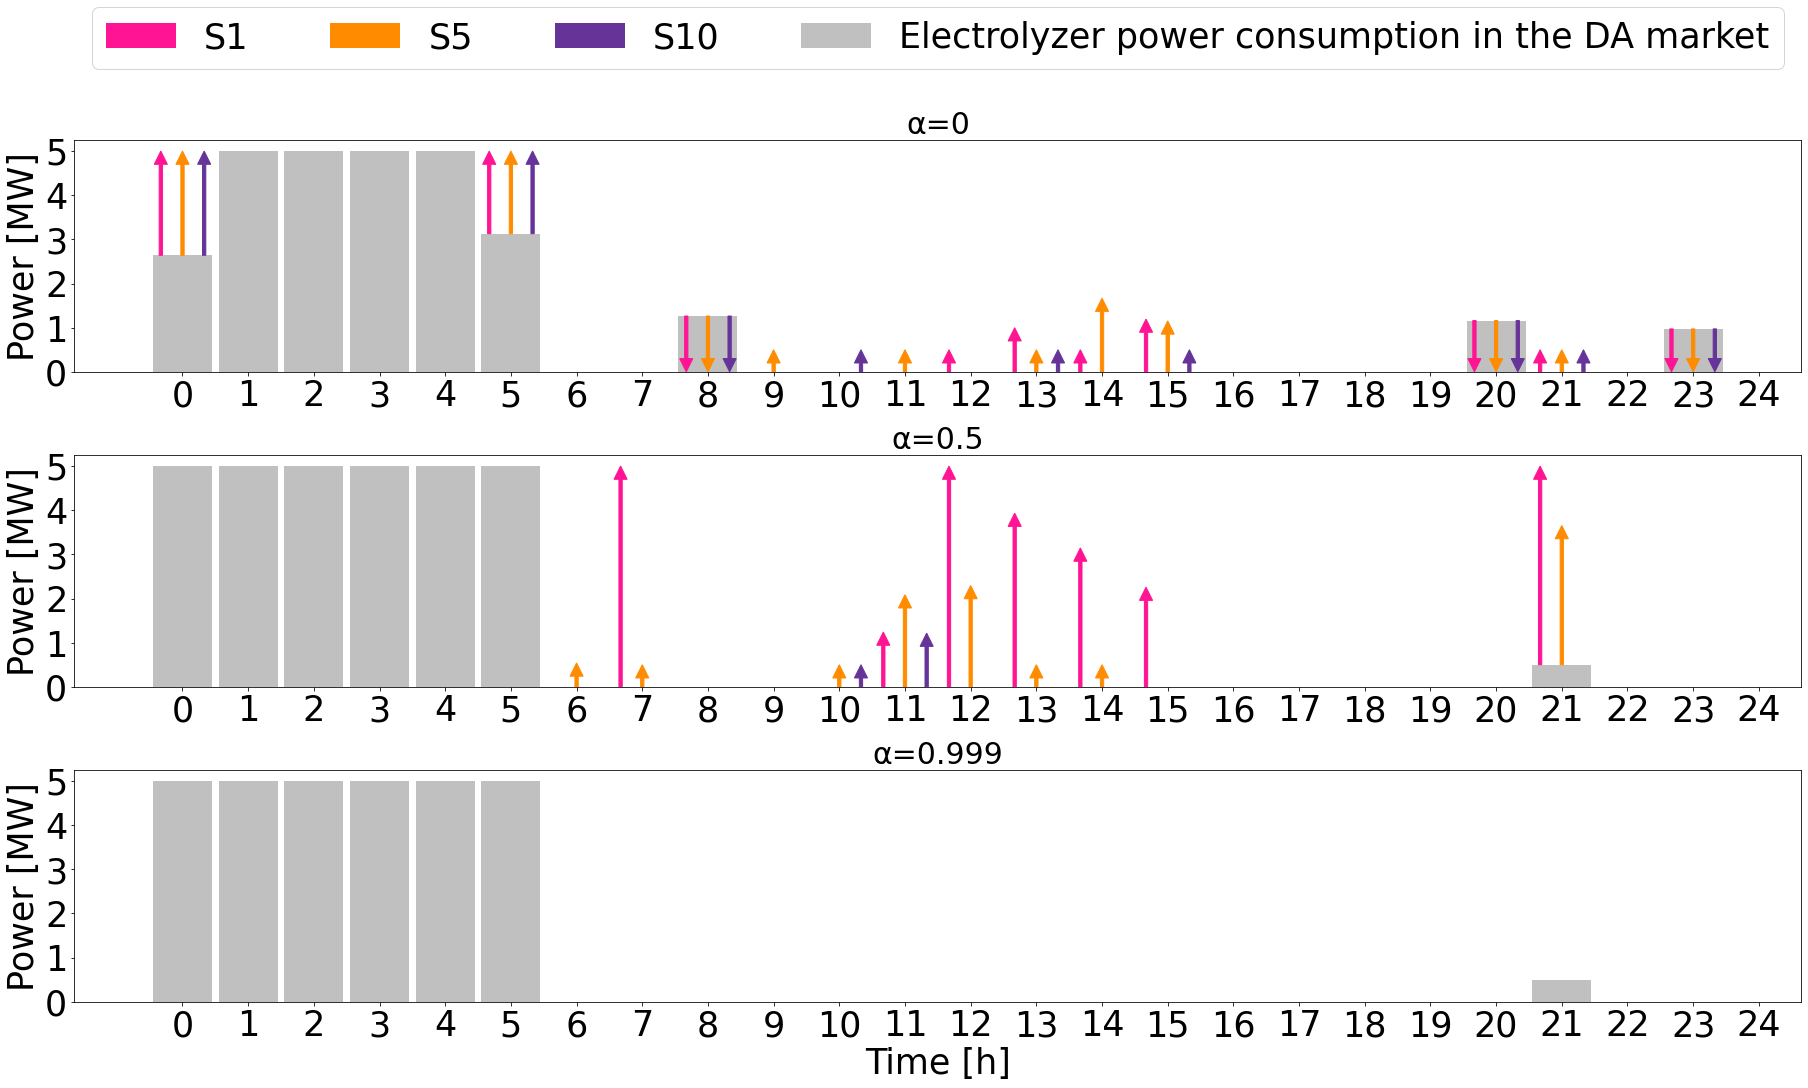

In [24]:
X = np.arange(25)
Y = np.arange(6)


width = 0.9
hw = 0.2
hl = 0.3
arrow_width = 0.05
zero_tolerance = 1e-9

fig, axs = plt.subplots(
    3, 1,
    figsize=(25, 15),
    constrained_layout=True
)


scenarios = [
    (1, -0.33, "deeppink"),
    (5, 0.00, "darkorange"),
    (10, 0.33, "rebeccapurple")
]


def draw_arrow(ax, x, y, dy, color):
    dy = float(dy)

    if not np.isfinite(dy):
        raise ValueError(
            f"Invalid arrow length at x={x}: {dy}"
        )

    if abs(dy) <= zero_tolerance:
        return

    ax.arrow(
        x, y, 0, dy,
        color=color,
        length_includes_head=True,
        head_width=hw,
        head_length=hl,
        width=arrow_width
    )


def draw_panel(ax, electrolyzer_da, alpha_key, title):

    for i in range(24):
        base_value = float(electrolyzer_da[i])

        ax.bar(
            X[i],
            base_value,
            width,
            color="silver"
        )

        for scenario, offset, color in scenarios:
            
            upward_arrow = (
                scenario_alpha_data_el_plus[scenario][alpha_key][i]
            )

            
            downward_arrow = (
                -scenario_alpha_data_el_minus[scenario][alpha_key][i]
            )

            draw_arrow(
                ax,
                X[i] + offset,
                base_value,
                upward_arrow,
                color
            )

            draw_arrow(
                ax,
                X[i] + offset,
                base_value,
                downward_arrow,
                color
            )

    ax.set_title(title, fontsize=30)
    ax.set_ylabel("Power [MW]", fontsize=35)
    ax.set_xticks(X)
    ax.set_xticklabels(X)
    ax.set_yticks(Y)
    ax.set_yticklabels(Y)
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=35
    )


    ax.grid(False)




draw_panel(
    axs[0],
    elDA1,
    1,
    "α=0"
)

draw_panel(
    axs[1],
    elDA6,
    6,
    "α=0.5"
)

draw_panel(
    axs[2],
    elDA11,
    11,
    "α=0.999"
)


axs[2].set_xlabel("Time [h]", fontsize=35)


legend_handles = [
    Patch(facecolor="deeppink", label="S1"),
    Patch(facecolor="darkorange", label="S5"),
    Patch(facecolor="rebeccapurple", label="S10"),
    Patch(
        facecolor="silver",
        label="Electrolyzer power consumption in the DA market"
    )
]

axs[0].legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0, 0.65, 1, 1),
    ncol=4,
    mode="expand",
    fontsize=35
)


fig.savefig(
    "fig_15.pdf",
    format="pdf",
    dpi=100,
    bbox_inches="tight"
)

plt.show()